
### Лабораторная работа: 
### Тема: Декодирование DTMF сигнала
ИТМО, «Речевые технологии и машинное обучение»

по курсу «Цифровая обработка сигналов»

преподаватель: Рыбин Сергей Витальевич

выполнила: Пелсе Александра Владимировна

группа: М4121

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
from IPython.display import Audio
import wave
from scipy.fft import fft, fftfreq

In [30]:
file_path = 'DTMF_Lab7.wav'
y, sr = librosa.load(file_path, sr=None)

211680
частота дискреизации: 44100


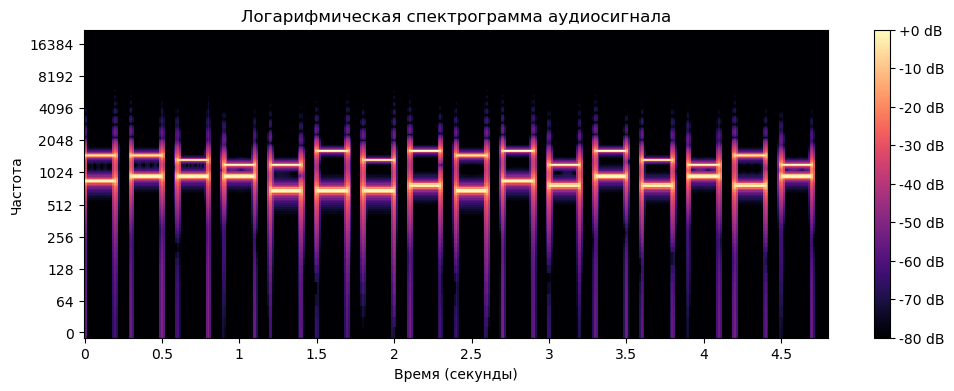

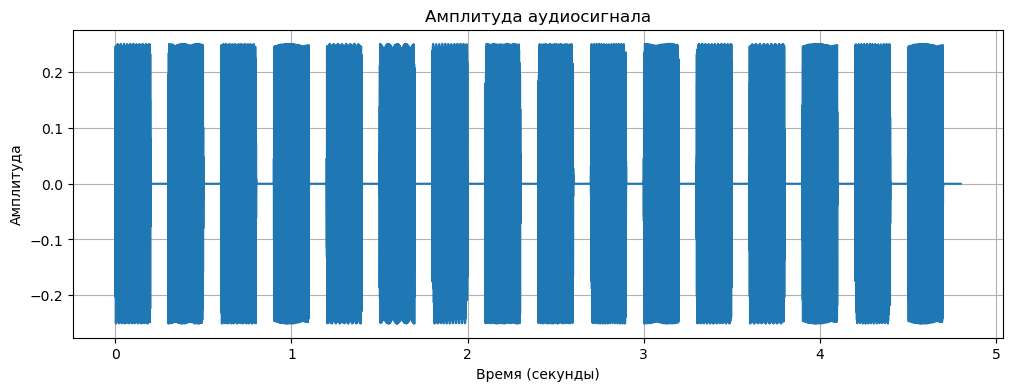

In [31]:
print(len(y))
print("частота дискреизации:", sr)

# Построение спектрограммы log
def plot_spectrogram(signal, sr, title="Логарифмическая спектрограмма аудиосигнала"):
    plt.figure(figsize=(12, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(signal)), ref=np.max)
    librosa.display.specshow(D, x_axis='time', y_axis='log', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Время (секунды)')       # Подписываем оси
    plt.ylabel('Частота')
    plt.title(title)
    plt.show()

# Построение амплитуды сигнала
def plot_oscillogram(y, sr):
    # Вычисляем длительность сигнала в секундах
    duration = len(y) / sr
    # Создаем временную ось
    times = np.linspace(0, duration, len(y))
    plt.figure(figsize=(12, 4))  # Устанавливаем размер окна графика
    plt.plot(times, y)           # Строим график амплитуды относительно времени
    plt.title('Амплитуда аудиосигнала')   # Добавляем заголовок
    plt.xlabel('Время (секунды)')       # Подписываем оси
    plt.ylabel('Амплитуда')
    plt.grid(True)                      # Включаем сетку
    plt.show()


plot_spectrogram(y, sr)
plot_oscillogram(y, sr)

# Воспроизводим новый файл
audio = Audio(filename=file_path)
display(audio)

### Задача
1) Входные данные: аудио сигнал 𝑥 с частотой дискретизации 𝐹𝑑 = 44100 Hz, 16 Bit, Mono, PCM wave file.
2) В сигнале 𝑥 с помощью DTMF кодирования прописана последовательность различных цифр (и управляющих клавиш) телефона.
3) Длина каждого элемента звуковой последовательности 200 mc, паузы между ними по 100 mc.
4) Задача: С помощью алгоритм Герцеля декодировать сигнал и восстановить исходную последовательность.

Информация:

в алгоритме Герцеля при вычислении компоненты спектра 𝑋(𝑘) для величины 𝛼 = 2𝜋𝑘 / 𝑁 используется 𝑘 — номер компоненты спектра. Вычислить его можно по формуле: 𝑘 = [ 𝑓 ∗ 𝑁 / 𝐹𝑑 ], где 𝑓 — текущая частота DTMF, 𝐹𝑑 — частота дискретизации, 𝑁 — длина ДПФ.

#### Шаг 1
Разберу сигнал на отдельные сегменты полезного сигнала, исключая паузы.

In [32]:
# Путь к файлу
file_path = 'DTMF_Lab7.wav'

# Загрузка сигнала
y, sr = librosa.load(file_path, sr=None)

# Длительность полезного сигнала и паузы в секундах
useful_duration_sec = 0.2  # 200 ms
pause_duration_sec = 0.1    # 100 ms

# Перевод секунд в индекс массива
useful_frames = int(useful_duration_sec * sr)
pause_frames = int(pause_duration_sec * sr)

# Количество сегментов
total_frames = len(y)
segments_count = total_frames // (useful_frames + pause_frames)

# Массив для хранения обработанных сегментов
segments = []

# Формирование отрезков полезного сигнала
start_frame = 0
for _ in range(segments_count):
    end_frame = start_frame + useful_frames
    segments.append(y[start_frame:end_frame])
    start_frame += useful_frames + pause_frames

# Проверка первых 3-х сегментов
for idx, seg in enumerate(segments[:3]):
    print(f"Сегмент {idx}: длина ДПФ {seg.shape}, первые 5 элементов {seg[:5]}...")

Сегмент 0: длина ДПФ (8820,), первые 5 элементов [0.         0.00064087 0.00253296 0.00558472 0.00952148]...
Сегмент 1: длина ДПФ (8820,), первые 5 элементов [0.         0.00067139 0.00265503 0.00576782 0.00985718]...
Сегмент 2: длина ДПФ (8820,), первые 5 элементов [0.         0.00064087 0.00250244 0.00549316 0.00942993]...


#### Шаг 2
Есть массив segments, содержащий отдельные временные участки сигнала. **Что дальше?**

Следующим шагом будет вычисление спектра (частот) для каждого отдельного сегмента.

Для этого:
- нужно применить быстрое преобразование Фурье (FFT) к каждому сегменту.
- Поскольку сегменты имеют одинаковую длину (8820 выборок), результирующая длина спектра будет постоянной (8820).
- Затем из полученного спектра нужно выбрать две наиболее выраженные частоты, соответствующие стандартному протоколу DTMF.

In [33]:
# Функция для извлечения частот
def extract_frequencies(segment, sr):
    """
    Возвращает пару основных частот для сегмента DTMF-сигнала.
    """
    # Выполняем быстрое преобразование Фурье
    N = len(segment)
    yf = fft(segment)
    xf = fftfreq(N, 1/sr)
    
    # Берем положительные частоты (левая половина спектра)
    positive_freqs = xf[:N//2]
    magnitudes = np.abs(yf[:N//2])
    
    # Ищем две наивысшие пиковые частоты
    indices = np.argsort(magnitudes)[::-1][:2]
    freq1 = positive_freqs[indices[0]]
    freq2 = positive_freqs[indices[1]]
    
    # Сортируем частоты для удобства (маленькая сначала)
    dominant_freqs = tuple(sorted([freq1, freq2]))
    return dominant_freqs

# Извлечение частоты для каждого сегмента
frequencies_per_segment = []
for idx, seg in enumerate(segments):
    dominant_freqs = extract_frequencies(seg, sr)
    frequencies_per_segment.append(dominant_freqs)
    print(f"Сегмент {idx}: главные частоты {dominant_freqs}")


Сегмент 0: главные частоты (np.float64(850.0), np.float64(1475.0))
Сегмент 1: главные частоты (np.float64(940.0), np.float64(1475.0))
Сегмент 2: главные частоты (np.float64(940.0), np.float64(1335.0))
Сегмент 3: главные частоты (np.float64(940.0), np.float64(1210.0))
Сегмент 4: главные частоты (np.float64(695.0), np.float64(1210.0))
Сегмент 5: главные частоты (np.float64(695.0), np.float64(1635.0))
Сегмент 6: главные частоты (np.float64(695.0), np.float64(1335.0))
Сегмент 7: главные частоты (np.float64(770.0), np.float64(1635.0))
Сегмент 8: главные частоты (np.float64(695.0), np.float64(1475.0))
Сегмент 9: главные частоты (np.float64(850.0), np.float64(1635.0))
Сегмент 10: главные частоты (np.float64(770.0), np.float64(1210.0))
Сегмент 11: главные частоты (np.float64(940.0), np.float64(1635.0))
Сегмент 12: главные частоты (np.float64(770.0), np.float64(1335.0))
Сегмент 13: главные частоты (np.float64(940.0), np.float64(1210.0))
Сегмент 14: главные частоты (np.float64(770.0), np.float64

#### Наблюдения:
я вижу, что полученные значения близки к значениям из таблицы частот DTMF, но отличаются на 2 единицы.
Я не хочу, чтобы они отличались от табличных значений, поэтому я буду округлять по-другому.

In [34]:
# вспомогательная функция для округления до ближайших значений из таблицы DTMF
def nearest_standard_frequency(freq):
    """Возвращает ближайшую стандартную частоту из таблицы DTMF."""
    standard_freqs = [697, 770, 852, 941, 1209, 1336, 1477, 1633]
    closest_idx = np.argmin(np.abs(np.array(standard_freqs) - freq))
    return standard_freqs[closest_idx]

# Переопределяю функцию, чтобы использовать nearest_standard_frequency()
# Функция для извлечения частот
def extract_frequencies(segment, sr):
    """
    Возвращает пару основных частот для сегмента DTMF-сигнала.
    """
    # Выполняем быстрое преобразование Фурье
    N = len(segment)
    yf = fft(segment)
    xf = fftfreq(N, 1/sr)
    
    # Берём положительные частоты (левая половина спектра)
    positive_freqs = xf[:N//2]
    magnitudes = np.abs(yf[:N//2])
    
    # Ищем две наивысшие пиковые частоты
    indices = np.argsort(magnitudes)[::-1][:2]
    freq1 = positive_freqs[indices[0]]
    freq2 = positive_freqs[indices[1]]
    
    # Округляем частоты до стандартных значений
    rounded_freq1 = nearest_standard_frequency(freq1)
    rounded_freq2 = nearest_standard_frequency(freq2)
    
    # Сортируем частоты для удобства (маленькая сначала)
    dominant_freqs = tuple(sorted([rounded_freq1, rounded_freq2]))
    return dominant_freqs

# Извлечём частоты для каждого сегмента
frequencies_per_segment = []
for idx, seg in enumerate(segments):
    dominant_freqs = extract_frequencies(seg, sr)
    frequencies_per_segment.append(dominant_freqs)
    print(f"Сегмент {idx}: главные частоты {dominant_freqs}")

Сегмент 0: главные частоты (852, 1477)
Сегмент 1: главные частоты (941, 1477)
Сегмент 2: главные частоты (941, 1336)
Сегмент 3: главные частоты (941, 1209)
Сегмент 4: главные частоты (697, 1209)
Сегмент 5: главные частоты (697, 1633)
Сегмент 6: главные частоты (697, 1336)
Сегмент 7: главные частоты (770, 1633)
Сегмент 8: главные частоты (697, 1477)
Сегмент 9: главные частоты (852, 1633)
Сегмент 10: главные частоты (770, 1209)
Сегмент 11: главные частоты (941, 1633)
Сегмент 12: главные частоты (770, 1336)
Сегмент 13: главные частоты (941, 1209)
Сегмент 14: главные частоты (770, 1477)
Сегмент 15: главные частоты (941, 1209)


#### Шаг 3
Соотнести значения частот с таблицей DTMF

In [35]:
# Таблица соответствия частот и символов
dtmf_map = {
    (697, 1209): '1', (697, 1336): '2', (697, 1477): '3', (697, 1633): 'A',
    (770, 1209): '4', (770, 1336): '5', (770, 1477): '6', (770, 1633): 'B',
    (852, 1209): '7', (852, 1336): '8', (852, 1477): '9', (852, 1633): 'C',
    (941, 1209): '*', (941, 1336): '0', (941, 1477): '#', (941, 1633): 'D'
}

def decode_segment(segment):
    try:
        return dtmf_map[segment]
    except KeyError:
        print(f"Нет совпадения для частот {dominant_freq_pair}")
        return None

# Декодирование каждого сегмента
decoded_numbers = []
for segment in frequencies_per_segment:
    decoded_numbers.append(decode_segment(segment))

print("Распознанные символы:", ''.join([n for n in decoded_numbers if n]))

Распознанные символы: 9#0*1A2B3C4D5*6*


#### Наблюдения:
С помощью последовательных шагов и анализа каждого шага удалось декодировать DTMF ввод.
Результат:
##### 9#0*1A2B3C4D5*6*